In [1]:
!pip install gdown -q

FILE_ID = "1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS"
!gdown --id {FILE_ID} -O dataset.zip

!unzip -q dataset.zip -d /content/dataset
print("Done.")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS
From (redirected): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS&confirm=t&uuid=ee74f3da-b5d9-467e-95b4-0eb8e6ab511b
To: /content/dataset.zip
100% 4.08G/4.08G [02:34<00:00, 26.4MB/s]
Done.


## Eye Disease Classes Overview

| Class | Description | Key Fundus Signs |
|---|---|---|
| **Normal** | Healthy retina with no detectable pathology | Clear optic disc, normal vessel pattern, no lesions |
| **Diabetic Retinopathy (DR)** | Retinal damage caused by long-term diabetes affecting blood vessels | Microaneurysms, hemorrhages, exudates, neovascularization in advanced stages |
| **Glaucoma** | Progressive optic nerve damage, often linked to elevated eye pressure | Enlarged cup-to-disc ratio, optic disc pallor or notching |
| **Cataract** | Clouding of the eye's lens, not the retina itself | Hazy, blurred, low-contrast fundus image due to opacity in front of the retina |
| **AMD (Age-related Macular Degeneration)** | Degeneration of the macula, affecting central vision | Drusen deposits, pigmentary changes near the macula |
| **Hypertension** | Retinal damage from chronic high blood pressure | Arteriovenous nicking, flame-shaped hemorrhages, cotton wool spots |
| **Myopia** | Pathologic nearsightedness-related retinal and optic disc changes | Tilted/crescent-shaped optic disc, retinal thinning, tessellated fundus appearance |
| **Others** | Catch-all category for conditions outside the above 7 classes | Heterogeneous — mixed and varied presentations |

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

meta = pd.read_csv("/content/dataset/metadata.csv")
val_df = pd.read_csv("/content/dataset/splits/val.csv")

remaining = meta[~meta['filename'].isin(val_df['filename'])].reset_index(drop=True)

train_df, test_df = train_test_split(
    remaining, test_size=0.1, stratify=remaining['unified_label'], random_state=42
)

train_df.to_csv("/content/dataset/splits/train.csv", index=False)
test_df.to_csv("/content/dataset/splits/test.csv", index=False)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 9577 | Val: 1197 | Test: 1065


In [3]:
from PIL import Image
import os, hashlib
from collections import Counter
import numpy as np

img_dir = "/content/dataset/images"

corrupt_files = []
sizes, formats, modes = [], [], []
hashes = {}
duplicate_pairs = []

for fname in meta['filename']:
    path = os.path.join(img_dir, fname)
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            sizes.append(im.size); formats.append(im.format); modes.append(im.mode)
        with open(path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in hashes:
            duplicate_pairs.append((hashes[file_hash], fname))
        else:
            hashes[file_hash] = fname
    except Exception as e:
        corrupt_files.append((fname, str(e)))

print(f"Corrupt images: {len(corrupt_files)}")
print(f"Unique dimensions: {len(set(sizes))}")
print(f"Exact duplicate pairs: {len(duplicate_pairs)}")

# Fix cross-split leakage: keep in train, drop from val/test
split_lookup = {}
for fname in train_df['filename']: split_lookup[fname] = 'train'
for fname in val_df['filename']: split_lookup[fname] = 'val'
for fname in test_df['filename']: split_lookup[fname] = 'test'

leakage = [(a, b, split_lookup.get(a), split_lookup.get(b)) for a, b in duplicate_pairs
           if split_lookup.get(a) != split_lookup.get(b)]

priority = {'train': 0, 'test': 1, 'val': 2}
files_to_drop = set()
for a, b, sa, sb in leakage:
    files_to_drop.add(b if priority[sa] <= priority[sb] else a)

train_df = train_df[~train_df['filename'].isin(files_to_drop)].reset_index(drop=True)
val_df   = val_df[~val_df['filename'].isin(files_to_drop)].reset_index(drop=True)
test_df  = test_df[~test_df['filename'].isin(files_to_drop)].reset_index(drop=True)

train_df.to_csv("/content/dataset/splits/train.csv", index=False)
val_df.to_csv("/content/dataset/splits/val.csv", index=False)
test_df.to_csv("/content/dataset/splits/test.csv", index=False)

print(f"\nLeakage fixed. Dropped {len(files_to_drop)} files.")
print(f"Final — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Corrupt images: 0
Unique dimensions: 465
Exact duplicate pairs: 126

Leakage fixed. Dropped 39 files.
Final — Train: 9577 | Val: 1176 | Test: 1047


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight

IMG_DIR = "/content/dataset/images"
IMG_SIZE = 224

classes_sorted = sorted(train_df['unified_label'].unique())
label_to_idx = {cls: i for i, cls in enumerate(classes_sorted)}
idx_to_label = {i: cls for cls, i in label_to_idx.items()}
print("Label mapping:", label_to_idx)

MINORITY_CLASSES = {'Cataract', 'Myopia', 'AMD', 'Hypertension'}

standard_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

heavy_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, df, img_dir, label_to_idx, standard_transform,
                 heavy_transform=None, minority_classes=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_to_idx = label_to_idx
        self.standard_transform = standard_transform
        self.heavy_transform = heavy_transform
        self.minority_classes = minority_classes or set()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert("RGB")
        if self.heavy_transform is not None and row['unified_label'] in self.minority_classes:
            image = self.heavy_transform(image)
        else:
            image = self.standard_transform(image)
        label = self.label_to_idx[row['unified_label']]
        return image, label

train_dataset = FundusDataset(train_df, IMG_DIR, label_to_idx, standard_transform, heavy_transform, MINORITY_CLASSES)
val_dataset   = FundusDataset(val_df,   IMG_DIR, label_to_idx, eval_transform)
test_dataset  = FundusDataset(test_df,  IMG_DIR, label_to_idx, eval_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.array(classes_sorted), y=train_df['unified_label'].values)
class_weight_dict = dict(zip(classes_sorted, class_weights_arr))
sample_weights = train_df['unified_label'].map(class_weight_dict).values
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, persistent_workers=True)
imgs, labels = next(iter(train_loader))
print("Batch shape:", imgs.shape)
print("Label distribution in batch:", torch.bincount(labels, minlength=len(classes_sorted)))

Label mapping: {'AMD': 0, 'Cataract': 1, 'Diabetic Retinopathy': 2, 'Glaucoma': 3, 'Hypertension': 4, 'Myopia': 5, 'Normal': 6, 'Others': 7}
Train: 9577 | Val: 1176 | Test: 1047
Batch shape: torch.Size([32, 3, 224, 224])
Label distribution in batch: tensor([6, 6, 4, 2, 1, 4, 5, 4])


In [5]:
for imgs, labels in train_loader:
    print("Batch shape:", imgs.shape)
    print("Label distribution in batch:", torch.bincount(labels, minlength=len(classes_sorted)))
    break  # only look at the first batch, but iterate "properly" via for-loop

Batch shape: torch.Size([32, 3, 224, 224])
Label distribution in batch: tensor([4, 7, 2, 1, 4, 4, 5, 5])


CNN from scratch

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout2d=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.skip = nn.Identity() if in_channels == out_channels else nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1), nn.BatchNorm2d(out_channels)
        )
        self.dropout2d = nn.Dropout2d(dropout2d) if dropout2d > 0 else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        return self.dropout2d(out)

class ScratchResCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.block1 = ResidualBlock(32, 32); self.pool1 = nn.MaxPool2d(2)
        self.block2 = ResidualBlock(32, 64); self.pool2 = nn.MaxPool2d(2)
        self.block3 = ResidualBlock(64, 128, dropout2d=0.1); self.pool3 = nn.MaxPool2d(2)
        self.block4 = ResidualBlock(128, 256, dropout2d=0.2); self.pool4 = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.pool4(self.block4(x))
        x = self.gap(x)
        return self.classifier(x)

model = ScratchResCNN(num_classes=8)
sample_input = torch.randn(2, 3, 224, 224)
print("Output shape:", model(sample_input).shape)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([2, 8])
Total parameters: 1,261,768


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum() if self.reduction == 'sum' else focal_loss

In [8]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ScratchResCNN(num_classes=8).to(device)

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.array(classes_sorted), y=train_df['unified_label'].values)
alpha_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=None, gamma=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

NUM_EPOCHS = 40
PATIENCE = 10
best_val_f1 = -1
epochs_no_improve = 0
best_model_state = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_macro_f1": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.3f}")

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_macro_f1 = f1_score(all_labels, all_preds, average='macro')
    scheduler.step(val_macro_f1)

    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} Macro-F1: {val_macro_f1:.3f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best val macro-F1: {best_val_f1:.3f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
torch.save(best_model_state, "/content/scratch_cnn_best.pth")
print(f"\nTraining complete. Best val macro-F1: {best_val_f1:.3f}")

Using device: cuda


Epoch 1/40 [Train]:   0%|          | 0/300 [00:02<?, ?it/s]

Epoch 1/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/40 | Train Loss: 1.6086 Acc: 0.270 | Val Loss: 1.7435 Acc: 0.177 Macro-F1: 0.154
  -> New best val macro-F1: 0.154 (checkpoint saved)


Epoch 2/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 34/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 34/40 | Train Loss: 0.5226 Acc: 0.681 | Val Loss: 0.8972 Acc: 0.463 Macro-F1: 0.345
  -> No improvement for 9/10 epochs


Epoch 35/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 35/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 35/40 | Train Loss: 0.5228 Acc: 0.688 | Val Loss: 0.9217 Acc: 0.453 Macro-F1: 0.341
  -> No improvement for 10/10 epochs
Early stopping triggered at epoch 35

Training complete. Best val macro-F1: 0.395


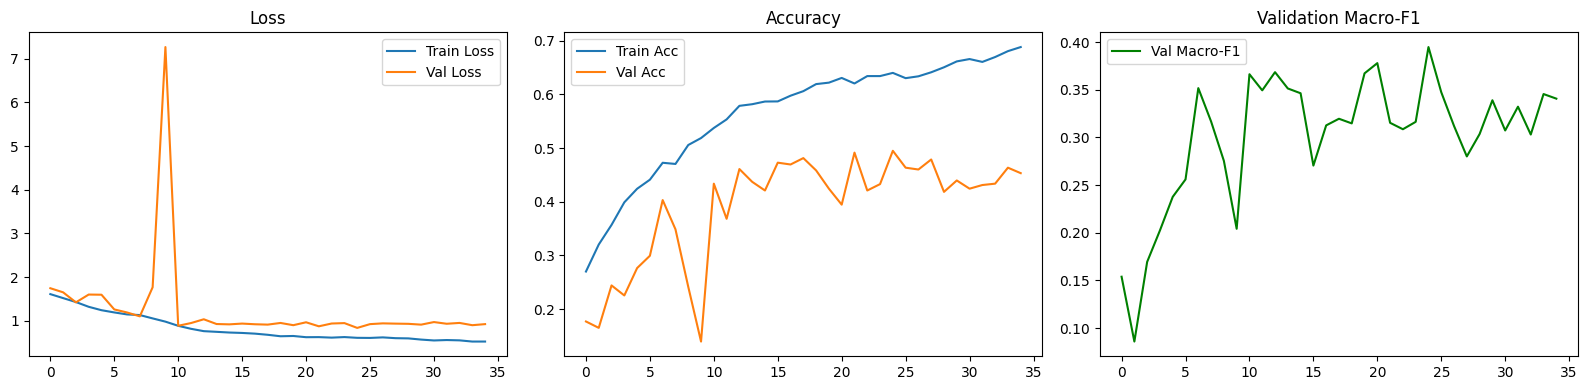

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history["train_loss"], label="Train Loss"); axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["train_acc"], label="Train Acc"); axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(history["val_macro_f1"], label="Val Macro-F1", color='green')
axes[2].set_title("Validation Macro-F1"); axes[2].legend()
plt.tight_layout()
plt.savefig("/content/scratch_cnn_training_curves.png", dpi=150)
plt.show()

Testing:   0%|          | 0/33 [00:00<?, ?it/s]

=== Scratch CNN — Test Set Classification Report ===

                      precision    recall  f1-score   support

                 AMD      0.000     0.000     0.000        25
            Cataract      0.667     0.194     0.300        31
Diabetic Retinopathy      0.918     0.381     0.538       352
            Glaucoma      0.312     0.571     0.403        84
        Hypertension      0.000     0.000     0.000         8
              Myopia      0.800     0.615     0.696        26
              Normal      0.701     0.583     0.636       422
              Others      0.182     0.657     0.284        99

            accuracy                          0.492      1047
           macro avg      0.447     0.375     0.357      1047
        weighted avg      0.673     0.492     0.523      1047



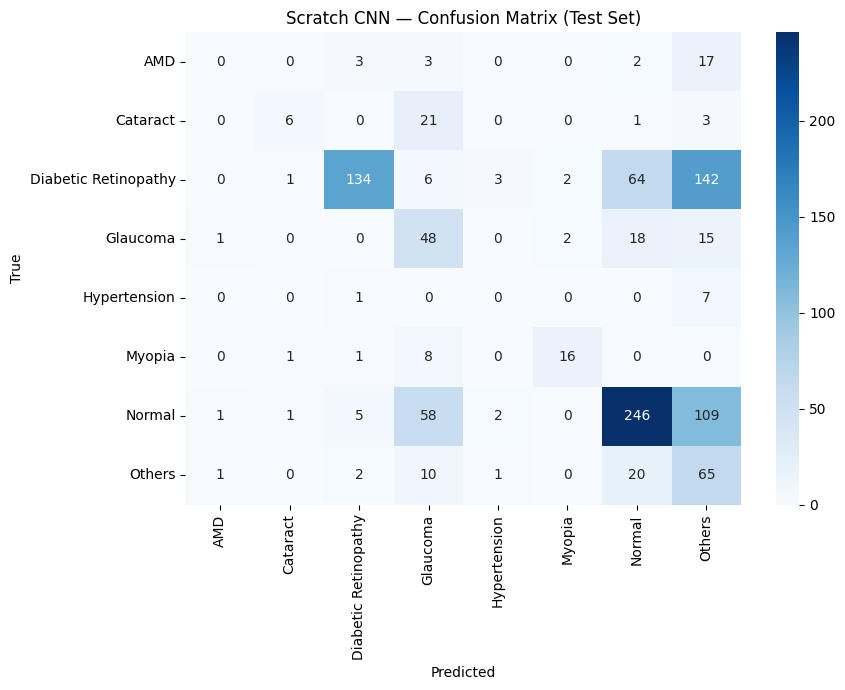

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

target_names = [idx_to_label[i] for i in range(len(classes_sorted))]
report = classification_report(test_labels, test_preds, target_names=target_names, digits=3)
print("=== Scratch CNN — Test Set Classification Report ===\n")
print(report)

with open("/content/scratch_cnn_test_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Scratch CNN — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("/content/scratch_cnn_confusion_matrix.png", dpi=150)
plt.show()

In [11]:
from google.colab import files

# Save full checkpoint (weights + metadata needed to reconstruct the model)
checkpoint = {
    "model_state_dict": best_model_state,
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label,
    "img_size": IMG_SIZE,
    "architecture": "ScratchResCNN",
    "num_classes": len(classes_sorted),
}
torch.save(checkpoint, "/content/scratch_cnn_checkpoint.pth")

files.download("/content/scratch_cnn_checkpoint.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import json

# Save scratch CNN history + test predictions so comparison survives a runtime restart
with open("/content/scratch_cnn_history.json", "w") as f:
    json.dump(history, f)

np.save("/content/scratch_cnn_test_preds.npy", np.array(test_preds))
np.save("/content/scratch_cnn_test_labels.npy", np.array(test_labels))

print("Scratch CNN results saved to disk.")

Scratch CNN results saved to disk.


resnet

In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ImageNet-pretrained ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze early layers (generic features: edges, textures) — keep pretrained knowledge intact
for name, param in resnet.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Replace the final FC layer for 8-class output
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 8)   # raw logits, no softmax — same convention as scratch CNN
)

resnet = resnet.to(device)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} total")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


Trainable parameters: 22,079,496 / 23,524,424 total


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import copy

criterion_resnet = FocalLoss(alpha=None, gamma=1.0)  # same loss setup as the fixed scratch CNN

# Differential LR: smaller for unfrozen backbone, larger for new head
optimizer_resnet = torch.optim.Adam([
    {"params": resnet.layer3.parameters(), "lr": 1e-5},
    {"params": resnet.layer4.parameters(), "lr": 1e-5},
    {"params": resnet.fc.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='max', factor=0.5, patience=3)

NUM_EPOCHS = 40
PATIENCE = 10
best_val_f1_resnet = -1
epochs_no_improve = 0
best_resnet_state = None

resnet_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_macro_f1": []}

for epoch in range(NUM_EPOCHS):
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"[ResNet] Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = resnet(imgs)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.3f}")

    train_loss = running_loss / total
    train_acc = correct / total

    resnet.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    val_bar = tqdm(val_loader, desc=f"[ResNet] Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = resnet(imgs)
            loss = criterion_resnet(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_macro_f1 = f1_score(all_labels, all_preds, average='macro')
    scheduler_resnet.step(val_macro_f1)

    resnet_history["train_loss"].append(train_loss); resnet_history["val_loss"].append(val_loss)
    resnet_history["train_acc"].append(train_acc); resnet_history["val_acc"].append(val_acc)
    resnet_history["val_macro_f1"].append(val_macro_f1)

    print(f"[ResNet] Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} Macro-F1: {val_macro_f1:.3f}")

    if val_macro_f1 > best_val_f1_resnet:
        best_val_f1_resnet = val_macro_f1
        epochs_no_improve = 0
        best_resnet_state = copy.deepcopy(resnet.state_dict())
        print(f"  -> New best val macro-F1: {best_val_f1_resnet:.3f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

resnet.load_state_dict(best_resnet_state)
torch.save(best_resnet_state, "/content/resnet_best.pth")
print(f"\nResNet training complete. Best val macro-F1: {best_val_f1_resnet:.3f}")

# Persist immediately in case of disconnect
with open("/content/resnet_history.json", "w") as f:
    json.dump(resnet_history, f)

[ResNet] Epoch 1/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[ResNet] Epoch 1/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

[ResNet] Epoch 1/40 | Train Loss: 1.0584 Acc: 0.535 | Val Loss: 0.9260 Acc: 0.499 Macro-F1: 0.444
  -> New best val macro-F1: 0.444 (checkpoint saved)


[ResNet] Epoch 2/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[ResNet] Epoch 2/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

...

[ResNet] Epoch 8/40 | Train Loss: 0.3966 Acc: 0.779 | Val Loss: 0.8455 Acc: 0.567 Macro-F1: 0.407
  -> No improvement for 7/10 epochs


[ResNet] Epoch 9/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[ResNet] Epoch 9/40 [Val]:   0%|          | 0/37 [00:00<?, ?it/s]

[ResNet] Epoch 9/40 | Train Loss: 0.3872 Acc: 0.786 | Val Loss: 0.8740 Acc: 0.590 Macro-F1: 0.406
  -> No improvement for 8/10 epochs


[ResNet] Epoch 10/40 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resnet_history["train_loss"], label="Train Loss"); axes[0].plot(resnet_history["val_loss"], label="Val Loss")
axes[0].set_title("ResNet50 — Loss"); axes[0].legend()
axes[1].plot(resnet_history["train_acc"], label="Train Acc"); axes[1].plot(resnet_history["val_acc"], label="Val Acc")
axes[1].set_title("ResNet50 — Accuracy"); axes[1].legend()
axes[2].plot(resnet_history["val_macro_f1"], label="Val Macro-F1", color='green')
axes[2].set_title("ResNet50 — Validation Macro-F1"); axes[2].legend()
plt.tight_layout()
plt.savefig("/content/resnet_training_curves.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

resnet.eval()
resnet_test_preds, resnet_test_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing ResNet"):
        imgs = imgs.to(device)
        preds = resnet(imgs).argmax(dim=1)
        resnet_test_preds.extend(preds.cpu().numpy())
        resnet_test_labels.extend(labels.numpy())

target_names = [idx_to_label[i] for i in range(len(classes_sorted))]
resnet_report = classification_report(resnet_test_labels, resnet_test_preds, target_names=target_names, digits=3)
print("=== ResNet50 — Test Set Classification Report ===\n")
print(resnet_report)

with open("/content/resnet_test_report.txt", "w") as f:
    f.write(resnet_report)

np.save("/content/resnet_test_preds.npy", np.array(resnet_test_preds))
np.save("/content/resnet_test_labels.npy", np.array(resnet_test_labels))

cm = confusion_matrix(resnet_test_labels, resnet_test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("ResNet50 — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("/content/resnet_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from google.colab import files

resnet_checkpoint = {
    "model_state_dict": best_resnet_state,
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label,
    "img_size": IMG_SIZE,
    "architecture": "ResNet50_finetuned",
    "num_classes": len(classes_sorted),
}
torch.save(resnet_checkpoint, "/content/resnet_checkpoint.pth")
files.download("/content/resnet_checkpoint.pth")

In [ ]:
import json
import numpy as np
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import time

# Reload everything from disk (safe even after a runtime restart)
with open("/content/scratch_cnn_history.json") as f: scratch_hist = json.load(f)
with open("/content/resnet_history.json") as f: resnet_hist = json.load(f)

scratch_preds = np.load("/content/scratch_cnn_test_preds.npy")
scratch_labels = np.load("/content/scratch_cnn_test_labels.npy")
resnet_preds = np.load("/content/resnet_test_preds.npy")
resnet_labels = np.load("/content/resnet_test_labels.npy")

# --- 1. Training curve comparison ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(scratch_hist["val_loss"], label="Scratch CNN")
axes[0].plot(resnet_hist["val_loss"], label="ResNet50")
axes[0].set_title("Validation Loss"); axes[0].legend()

axes[1].plot(scratch_hist["val_acc"], label="Scratch CNN")
axes[1].plot(resnet_hist["val_acc"], label="ResNet50")
axes[1].set_title("Validation Accuracy"); axes[1].legend()

axes[2].plot(scratch_hist["val_macro_f1"], label="Scratch CNN")
axes[2].plot(resnet_hist["val_macro_f1"], label="ResNet50")
axes[2].set_title("Validation Macro-F1"); axes[2].legend()
plt.tight_layout()
plt.savefig("/content/comparison_training_curves.png", dpi=150)
plt.show()

# --- 2. Per-class F1 comparison (bar chart) ---
target_names = [idx_to_label[i] for i in range(len(classes_sorted))]

from sklearn.metrics import f1_score as f1s
scratch_f1_per_class = f1s(scratch_labels, scratch_preds, average=None, labels=range(len(classes_sorted)))
resnet_f1_per_class = f1s(resnet_labels, resnet_preds, average=None, labels=range(len(classes_sorted)))

x = np.arange(len(target_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, scratch_f1_per_class, width, label='Scratch CNN')
ax.bar(x + width/2, resnet_f1_per_class, width, label='ResNet50')
ax.set_xticks(x); ax.set_xticklabels(target_names, rotation=30, ha='right')
ax.set_ylabel("F1-score")
ax.set_title("Per-Class F1: Scratch CNN vs ResNet50 (Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/comparison_per_class_f1.png", dpi=150)
plt.show()

# --- 3. Overall metrics summary table ---
print("=== Overall Comparison ===")
print(f"Scratch CNN — Accuracy: {accuracy_score(scratch_labels, scratch_preds):.3f} | "
      f"Macro-F1: {f1_score(scratch_labels, scratch_preds, average='macro'):.3f}")
print(f"ResNet50    — Accuracy: {accuracy_score(resnet_labels, resnet_preds):.3f} | "
      f"Macro-F1: {f1_score(resnet_labels, resnet_preds, average='macro'):.3f}")

# --- 4. Inference speed benchmark (deployment consideration) ---
def benchmark_inference(model, n_runs=50):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    # warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
    torch.cuda.synchronize() if device.type == "cuda" else None

    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy_input)
    torch.cuda.synchronize() if device.type == "cuda" else None
    elapsed = time.time() - start
    return (elapsed / n_runs) * 1000  # ms per image

scratch_latency = benchmark_inference(model)      # 'model' = scratch CNN from earlier cells
resnet_latency = benchmark_inference(resnet)

scratch_params = sum(p.numel() for p in model.parameters())
resnet_params = sum(p.numel() for p in resnet.parameters())

print(f"\n=== Deployment Comparison ===")
print(f"Scratch CNN — Params: {scratch_params:,} | Avg inference: {scratch_latency:.2f} ms/image")
print(f"ResNet50    — Params: {resnet_params:,} | Avg inference: {resnet_latency:.2f} ms/image")